# Loading and Viewing Wyvern Data in Python

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Nrevyw/wyvern-public-resources/blob/main/tutorial-notebooks/loading-data/loading_data.ipynb)

This notebook details the code & process for visualizing Wyvern data. 

More details can be found on our Knowledge Centre at the following link:

https://knowledge.wyvern.space/#/using_wyvern_data/python/python.md

> **Note:** There are many ways to visualize raster data using Python. The combination of Rasterio + Matplotlib was chosen due to the simplicity & ability to build off of this code.

## Getting started
- **Google Colab (easiest):** open this notebook using the "Open in Colab" badge above, then run the cells top to bottom.
- **Local Jupyter:** run this notebook in your tool of choice (Jupyter Lab, Visual Studio Code, etc). The Setup cell below installs everything it needs, no environment to build ahead of time.

## Image we're using
Check out the image on the [Wyvern Open Data Catalog](https://opendata.wyvern.space/#/year/2024/wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a/wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a.json)!

This is L2A surface reflectance data, meaning atmospheric effects have already been corrected for and pixel values represent an estimate of ground reflectance rather than raw at-sensor radiance. 

## Band Combinations
We'll be exploring the following band combinations!

| Name | Red Channel | Green Channel | Blue Channel |
| ---- | ----------- | ------------- | ------------ |
| Natural Color (RGB) | 650nm | 550nm | 503nm |
| Color Infrared (CIR) | 750nm | 650nm | 550nm |


This notebook is self-contained and runs top to bottom in [Google Colab](https://colab.research.google.com/) or any local Jupyter install. Run the cell below first to install the packages it needs, then continue through the notebook. Nothing else needs to be set up.

In [1]:
# Install the packages this notebook needs.
%pip install -q numpy matplotlib requests rasterio

Note: you may need to restart the kernel to use updated packages.


In [2]:
# First, let's import our required packages
import json
import numpy as np
import rasterio
import matplotlib.pyplot as plt

## Download the Tutorial Files

Let's download the GeoTIFF and its STAC JSON metadata!

Run the cell below to download these files. Once the download is complete, they'll appear in the same folder as your notebook!

In [3]:
import requests
from pathlib import Path

IMAGE_URL = "https://wyvern-data.com/wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a/wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a.tiff"
JSON_URL = "https://wyvern-odp.com/wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a/wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a.json"

IMAGE_PATH = Path("wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a.tiff")
JSON_PATH = Path("wyvern_dragonette-001_20240930T070744_08fd7f5a_l2a.json")

downloads = [
    (IMAGE_URL, IMAGE_PATH),
    (JSON_URL, JSON_PATH),
]

for url, path in downloads:
    if path.exists():
        print(f"{path.name} File already here! Skipping download.")
    else:
        print(f"Downloading {path.name}...")
        response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
        response.raise_for_status()
        path.write_bytes(response.content)

print("Downloads complete!")

Downloads complete!


### Loading the Data

We'll start by reading the scale factor from the metadata JSON file we downloaded earlier. Wyvern's L2A products represent surface reflectance, but the values are stored as scaled 16-bit integers to reduce file size.

In [4]:
# Open the JSON metadata file and extract the scale factor
with open(JSON_PATH) as json_file:
    metadata = json.load(json_file)

# The scale factor converts stored uint16 reflectance values into their floating-point representation
scale_factor = metadata["assets"]["Cloud optimized GeoTiff"]["raster:bands"][0]["scale"]

# if you don't have the JSON file, you can hardcode the scale factor:
# scale_factor = 0.0001

print(f"Scale factor: {scale_factor}")

Scale factor: 0.0001


Now let's open the GeoTIFF using [rasterio](https://rasterio.readthedocs.io/en/stable/api/index.html). We'll replace any nodata pixels with `np.nan` so they are excluded from our calculations, then apply the scale factor to recover the floating-point reflectance values.

In [5]:
with rasterio.open(IMAGE_PATH) as image_file:
    # Convert to float so we can use np.nan and decimal values
    image_arr = image_file.read().astype(np.float32)
    nodata = image_file.nodata
    band_descriptions = image_file.descriptions

# Replace nodata pixels with NaN so they are excluded from calculations
if nodata is not None:
    image_arr[image_arr == nodata] = np.nan

# Apply the scale factor to recover floating-point reflectance values
image_arr *= scale_factor

print(f"Image shape: {image_arr.shape}")
print(f"Image bands: {', '.join(band_descriptions)}")

Image shape: (23, 7827, 5618)
Image bands: Band_503, Band_510, Band_519, Band_535, Band_549, Band_570, Band_584, Band_600, Band_614, Band_635, Band_649, Band_660, Band_669, Band_679, Band_690, Band_699, Band_711, Band_722, Band_734, Band_750, Band_764, Band_782, Band_799


## Building the Wavelength Map

Unlike a standard RGB image, each band in a hyperspectral GeoTIFF corresponds to a specific wavelength. We can find this information in the `eo:bands` field under the GeoTIFF asset in the STAC JSON we downloaded earlier, which lists each band's center wavelength. We'll read these out and build a map from wavelength to band index so we can select bands by wavelength rather than hardcoding band numbers.

In [6]:
with open(JSON_PATH) as json_file:
    metadata = json.load(json_file)

wavelength_map = {}
for i, band in enumerate(metadata["assets"]["Cloud optimized GeoTiff"]["eo:bands"]):
    wavelength = round(band["center_wavelength"] * 1000)  # convert from μm to nm
    wavelength_map[wavelength] = i

print(wavelength_map)

{503: 0, 510: 1, 519: 2, 535: 3, 549: 4, 570: 5, 584: 6, 600: 7, 614: 8, 635: 9, 649: 10, 660: 11, 669: 12, 679: 13, 690: 14, 699: 15, 711: 16, 722: 17, 734: 18, 750: 19, 764: 20, 782: 21, 799: 22}


### Selecting Bands by Wavelength

Now we'll write a small helper function that finds the nearest available band to any wavelength we ask for. This means if we request 550nm and the closest available band is 549nm, it'll find it automatically.

In [7]:
def get_band(wavelength_nm: int) -> np.ndarray:
    """
    Returns the image band closest to the requested wavelength.

    Args:
        wavelength_nm: Target wavelength in nanometres.

    Returns:
        A 2D array containing reflectance values for the closest available wavelength band.
    """
    available_wavelengths = list(wavelength_map.keys())
    closest_wavelength = min(
        available_wavelengths, key=lambda w: abs(w - wavelength_nm)
    )
    print(f"Requested {wavelength_nm}nm -- using {closest_wavelength}nm")
    return image_arr[wavelength_map[closest_wavelength]]

Now we're ready to plot our image plot using matplotlib!

Requested 650nm -- using 649nm
Requested 550nm -- using 549nm
Requested 503nm -- using 503nm


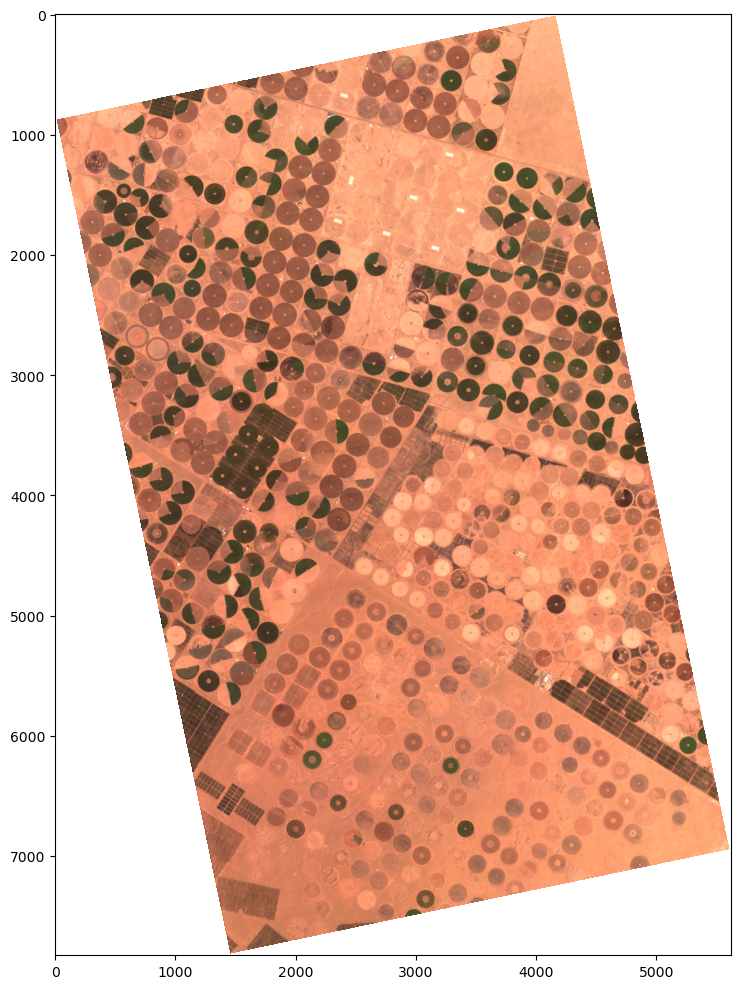

In [8]:
# Select our R, G, and B bands by wavelength, then stack them into a [rows, columns, channels]
# array which matplotlib expects
rgb_arr = np.dstack([get_band(650), get_band(550), get_band(503)]).astype(np.float32)

brightness_factor = 3  # Bring up the brightness a touch so we have a better visual
rgb_arr_bright = rgb_arr * brightness_factor
rgb_arr_bright = np.clip(rgb_arr_bright, 0, 1)  # keep values within 0-1

# We specify a larger figsize to get a better resolution out of the image. You can
# increase this further to further improve resolution! (at the expense of file size)
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
ax.imshow(rgb_arr_bright)

plt.tight_layout()
plt.show()

We can also render the image in color infrared by selecting a different set of bands from the image.

Requested 750nm -- using 750nm
Requested 650nm -- using 649nm
Requested 550nm -- using 549nm


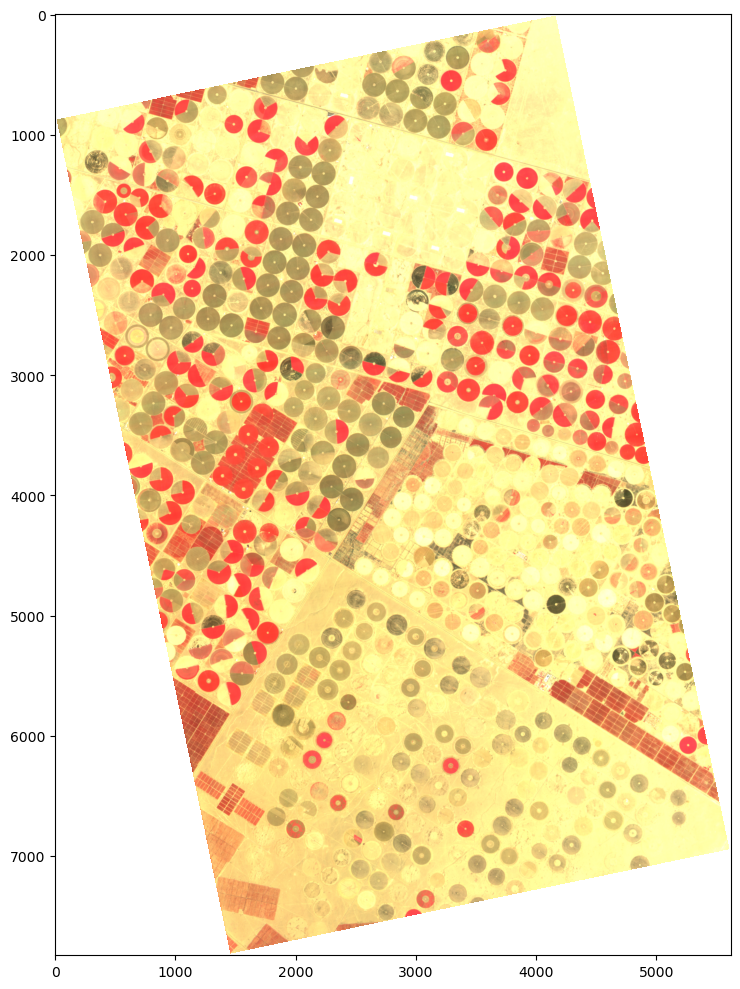

In [9]:
# Now, let's do the same with color infrared!
cir_arr = np.dstack([get_band(750), get_band(650), get_band(550)]).astype(np.float32)

cir_arr_bright = cir_arr * brightness_factor
cir_arr_bright = np.clip(cir_arr_bright, 0, 1)  # keep values within 0-1

fig, ax = plt.subplots(1, 1, figsize=(15, 10))
ax.imshow(cir_arr_bright)

plt.tight_layout()
plt.show()

Well done! You now know how to download and view Wyvern images in Python!
